# Per-variant temporal selection coefficient `s` — consolidated results

**Consolidated 2026-07-15** from 7 previously separate notebooks (`s_distribution_by_site`,
`s_histogram_by_site`, `s_ecdf_by_site`, `s_ecdf_difference_by_site`, `s_shiftfunction_by_site`,
`s_vs_climate`, `s_climate_slope`) after an audit found none of them redundant with each other —
each tests a genuinely different statistic, and an assumption that some were "superseded" by others
turned out wrong once checked directly. This notebook is now the single source for the **temporal s**
thread. (Parallelism / PicMin / `parallelism_by_site` are a separate, untouched thread this session —
not merged here.)

**`s`** = per-variant **plot-replicate selection coefficient** at a site = mean over the site's
~10–12 replicate plots of the OLS slope of $\mathrm{logit}(p)$ on generation (gen 0 = shared founding
frequency). Plots-as-replicates separate real selection (same direction across independent plots)
from drift. `s<0` = declining (purged), `s>0` = rising (favoured).

**Two genuinely different questions, two different answers:**
1. **Does the whole distribution of `s` shift** (SV vs frequency-matched SNP, at matched initial
   frequency)? → **Section 1: NULL.** A raw median comparison has a strong artifact (a Jensen/
   boundary effect of the logit statistic near 0/1, amplified for rare variants sitting on few
   founders) that a naive comparison doesn't remove; once de-trended (subtracting the per-p0-bin
   ALL-class-pooled median), the SV excess is ≈0.
2. **Is there a heavier PURGED TAIL for SVs, concentrated at hot/arid sites?** → **Sections 2-3:
   REAL.** Five independent views (histogram, ECDF, ECDF-difference, shift-function, vs-climate) plus
   climate-slope β all show the same pattern, insertion-driven. This is not the same statistic as (1)
   and is **not** explained by the artifact that nulled it — **Section 4** applies the identical
   de-trending correction directly to this signal and it survives, essentially unchanged.

**Standing caveats (apply to whatever in Sections 2-4 is real):**
- **Hitchhiking.** Global-mode kMate AF is a founder-mixture projection — cannot separate SV-specific
  selection from hitchhiking on a climate-purged haplotype (`GLOBAL_MODE_DECISION.md`). Local/window
  mode is not a clean fix (panel-incompleteness artifacts are deterministic and
  replicate-reproducible — they'd masquerade as this exact signal).
- **Insertion-polarity.** The signal is insertion-specific (reference-relative). Ruled out as a
  within-panel calling-confidence artifact (`F_MISSING`/`MA` checks), but not equivalent to true
  ancestral polarization — no outgroup exists in this repo. A *systematic* reference/mapping bias
  version of this caveat remains open.

See `SV_TEMPORAL_PURGING_SUMMARY.md` for the full audit narrative.

In [1]:

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
plt.rcParams.update({'figure.dpi':110, 'font.size':8, 'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/sv_adaptive"
COL = {"SNP":"#888888", "indel":"#0072B2", "SV":"#D55E00", "ins":"#D55E00", "del":"#009E73"}
rng = np.random.default_rng(0)
NBIN_MATCH, NDRAW = 25, 20000   # frequency-matching resample granularity, shared by all sections

def match_to(target_p0, src_s, src_p0):
    # resample src_s so its p0 distribution matches target_p0 (bin-stratified, with replacement)
    e = np.quantile(np.concatenate([target_p0, src_p0]), np.linspace(0, 1, NBIN_MATCH + 1)); e[-1] += 1e-9
    tb = np.digitize(target_p0, e[1:-1]); sb = np.digitize(src_p0, e[1:-1]); out = []
    for b in range(NBIN_MATCH):
        k = int(round((tb == b).mean() * NDRAW)); pool = src_s[sb == b]
        if k > 0 and pool.size: out.append(rng.choice(pool, k, replace=True))
    return np.concatenate(out) if out else np.array([])

# shared data: per-site raw (s, p0) subsamples for SNP/indel/SV (all SV; 25k SNP/indel subsample),
# the shared p0-decile bin edges, and the per-(site,stratum,class) de-trending baseline
npz = np.load(f"{G}/s_dist_by_stratum.npz")
long = pd.read_csv(f"{G}/s_dist_by_stratum.csv")
long["resid"] = long["median"] - long["base"]
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
p0q = npz["p0q"]; mids = 0.5 * (p0q[:-1] + p0q[1:]); NBIN = len(p0q) - 1
binf = lambda p: np.clip(np.digitize(p, p0q[1:-1]), 0, NBIN - 1)
base_lookup = long.set_index(["site", "stratum"])["base"].to_dict()
sites_npz = sorted({int(k.split("_")[0]) for k in npz.files if k.split("_")[0].isdigit()})
print(f"{len(meta)} sites, {long.stratum.nunique()} initial-frequency strata")


31 sites, 10 initial-frequency strata


## Section 1 — whole-distribution median shift, de-trended (VERIFIED NULL)

De-trended by initial frequency: raw median `s` vs $p_0$ has a strong NEG→POS slope that is an
artifact of the logit statistic at the 0/1 boundaries (reproduced by a zero-selection drift
simulation; median *linear* $\Delta p$ stays ~0), amplified because rare variants sit on few founders
(small effective $N_e$). We subtract the per-$p_0$-bin median of ALL variants (pooled, not
SNP-defined) so each panel shows $s_{\text{class}} - s_{\text{all}}$ at matched $p_0$: flat 0 =
behaves like same-frequency variants; below 0 = more purifying selection.

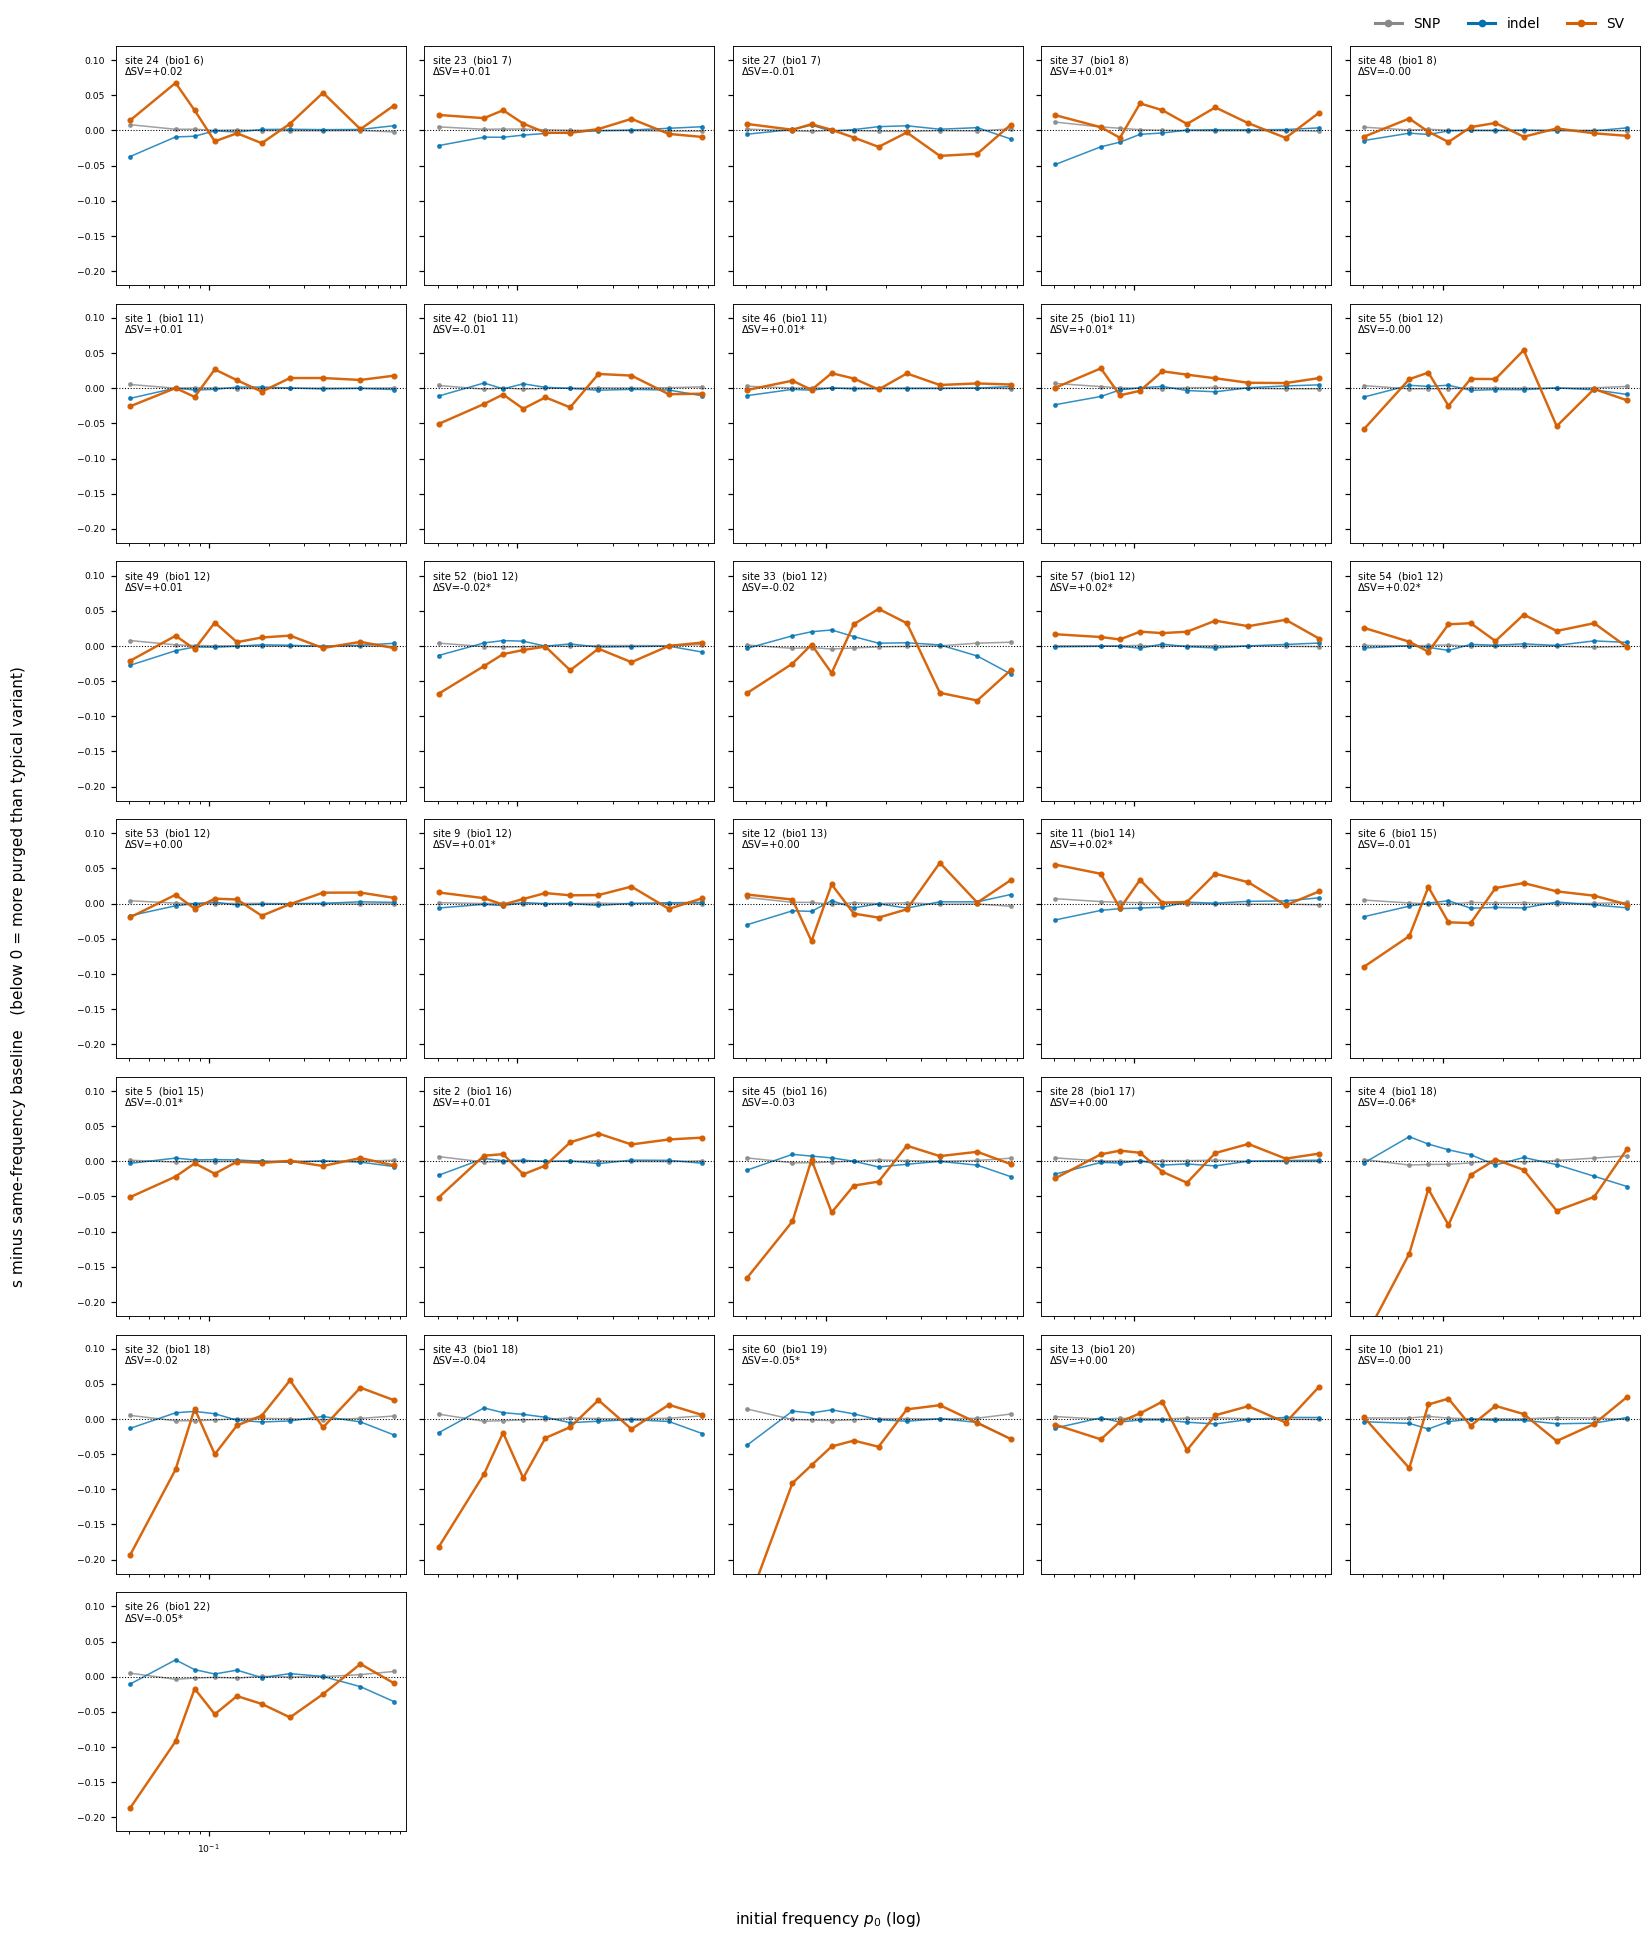

saved s_distribution_by_site.png  (* = Wilcoxon p<0.05 on per-stratum SV-vs-SNP shift)


In [2]:

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]:
    ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; d = long[long.site==s]
    for cls in ["SNP","indel","SV"]:
        dc = d[d.cls==cls].sort_values("stratum")
        if dc.empty: continue
        x = mids[dc.stratum.values]
        ax.plot(x, dc["resid"], "-", color=COL[cls], lw=1.6 if cls=="SV" else 1.0,
                marker="o", ms=3 if cls=="SV" else 2.2, label=cls, zorder=3 if cls=="SV" else 2,
                alpha=0.95 if cls=="SV" else 0.8)
    ax.axhline(0, color="k", lw=0.7, ls=":")
    mrow = meta[meta.site==s].iloc[0]
    star = "*" if (mrow.wil_p_sv==mrow.wil_p_sv and mrow.wil_p_sv<0.05) else ""
    ax.annotate(f"site {s}  (bio1 {mrow.bio1:.0f})\nΔSV={mrow.shift_sv:+.2f}{star}",
                xy=(0.03, 0.96), xycoords="axes fraction", va="top", ha="left", fontsize=6.5)
    ax.set_xscale("log"); ax.set_xlim(mids[0]*0.85, mids[-1]*1.15)
    ax.set_ylim(-0.22, 0.12)
    ax.tick_params(labelsize=6)
fig.supxlabel("initial frequency $p_0$ (log)", y=0.005, fontsize=10)
fig.supylabel("s minus same-frequency baseline   (below 0 = more purged than typical variant)",
              x=0.005, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,marker="o",ms=4,label=c)
                    for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.005))
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{G}/s_distribution_by_site.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved s_distribution_by_site.png  (* = Wilcoxon p<0.05 on per-stratum SV-vs-SNP shift)")


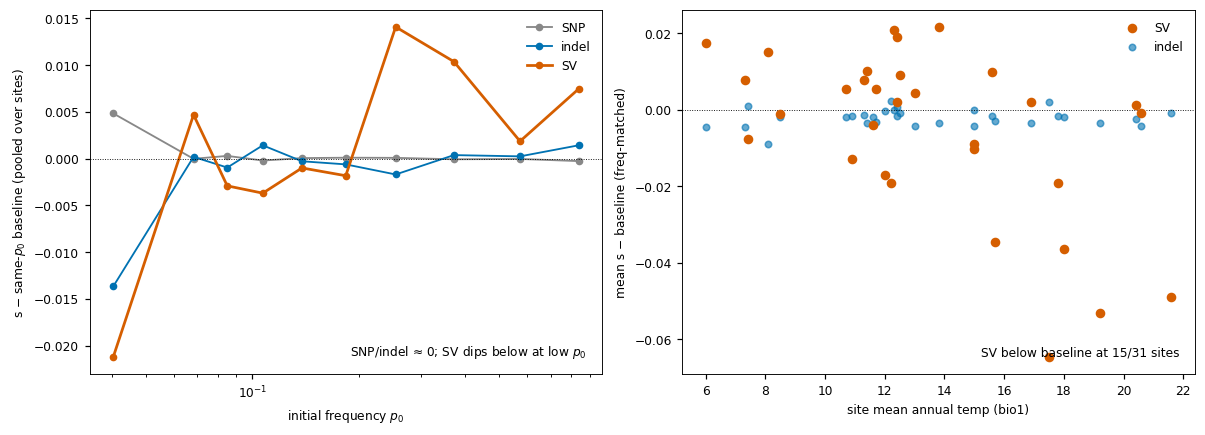

SV median excess-vs-baseline across sites = +0.0011 (below at 15/31)


In [3]:

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
piv = (long.groupby(["stratum","cls"])["resid"].median().unstack())
for cls in ["SNP","indel","SV"]:
    ax[0].plot(mids, piv[cls].values, "-o", color=COL[cls], lw=1.8 if cls=="SV" else 1.2, ms=4, label=cls)
ax[0].axhline(0, color="k", lw=0.6, ls=":"); ax[0].set_xscale("log")
ax[0].set_xlabel("initial frequency $p_0$"); ax[0].set_ylabel("s − same-$p_0$ baseline (pooled over sites)")
ax[0].annotate("SNP/indel ≈ 0; SV dips below at low $p_0$", xy=(0.97,0.05), xycoords="axes fraction",
               ha="right", fontsize=8)
ax[0].legend(frameon=False)
m = meta
ax[1].axhline(0, color="k", lw=0.6, ls=":")
ax[1].scatter(m.bio1, m.shift_sv, c="#D55E00", s=28, label="SV", zorder=3)
ax[1].scatter(m.bio1, m.shift_ind, c="#0072B2", s=18, alpha=.6, label="indel")
ax[1].set_xlabel("site mean annual temp (bio1)"); ax[1].set_ylabel("mean s − baseline (freq-matched)")
nneg = int((m.shift_sv<0).sum())
ax[1].annotate(f"SV below baseline at {nneg}/{len(m)} sites", xy=(0.97,0.05), xycoords="axes fraction",
               ha="right", fontsize=8)
ax[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/s_distribution_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"SV median excess-vs-baseline across sites = {m.shift_sv.median():+.4f} (below at {nneg}/{len(m)})")


**Section 1 takeaway (verified null):** once the logit/initial-frequency artifact is removed,
**SNP and indel sit on the neutral line (0)** at every frequency, and **SV excess-vs-baseline is ≈0**:
median +0.0011, negative at only **15/31 sites** (a minority, sign test n.s.). No genome-wide SV
purifying (or favoured) excess on this whole-distribution statistic. This does **not** mean SVs carry
no selection signal by any statistic — see Sections 2-4.

## Section 2 — tail-specific views (VERIFIED REAL): histogram, ECDF, ECDF-difference, shift-function, vs-climate

Five independent, complementary views of the same underlying question: not "does the whole
distribution shift" (Section 1, null), but **does SV have a heavier PURGED TAIL than a
frequency-matched SNP, and does it concentrate at hot/arid sites?** All five agree: yes. Frequency
matching throughout (SNP/indel resampled to the SV $p_0$ distribution per site); no de-trending in
this section (that check is Section 4).

### 2a. Raw histograms per site (common MAF; qualitative view)
Density histograms of `s` per class per site. If the orange (SV) histogram is shifted left of
grey/blue, SVs are under more purifying selection.

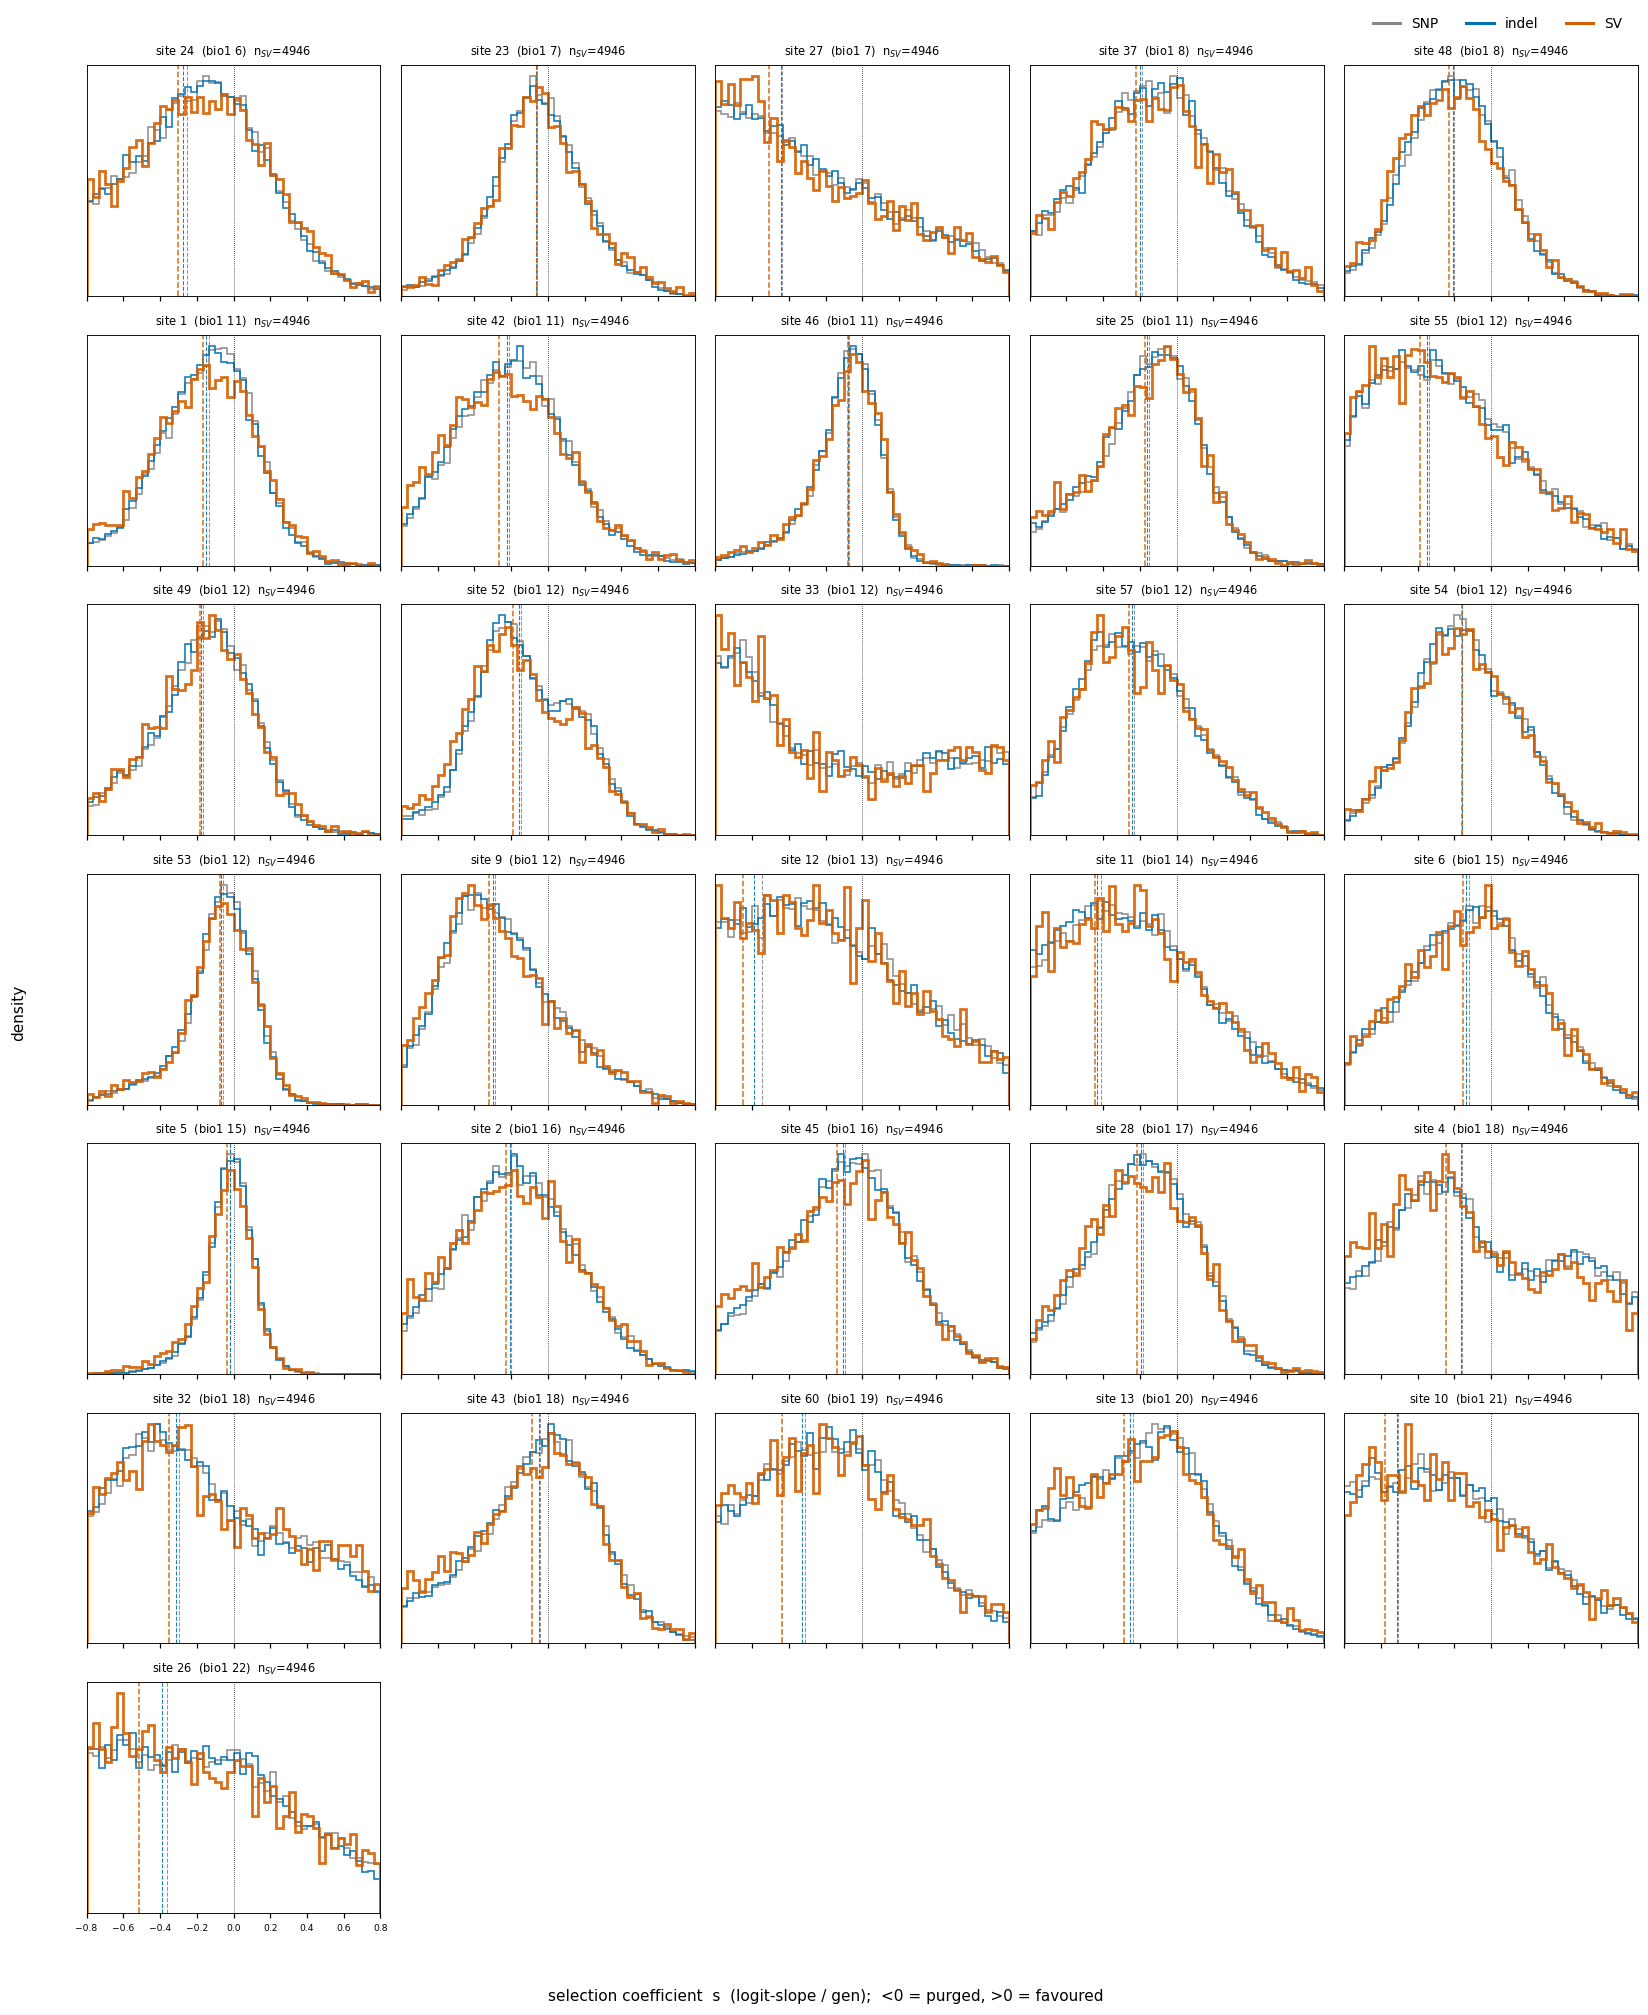

[RAW, not de-trended] median-s(SV) - median-s(SNP): median across sites -0.0330
SV median below SNP at 31/31 sites (sign p=0.000); indel-SNP median -0.0103 (≈0)
NOTE: this RAW whole-population median comparison is the one that Section 1's de-trending nulls (15/31 sites, n.s.) -- it is shown here for the qualitative distribution view only.


In [4]:

MAF_MIN = 0.0
XR = (-0.8, 0.8); BINS = np.linspace(*XR, 49)
def get(site, cls):
    s = npz[f"{site}_s_{cls}"]; p0 = npz[f"{site}_p0_{cls}"]
    m = np.minimum(p0, 1-p0) >= MAF_MIN
    return np.clip(s[m], *XR)

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.6*nrow), sharex=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; nsv = 0
    for cls in ["SNP","indel","SV"]:
        v = get(s, cls)
        if v.size == 0: continue
        if cls == "SV": nsv = v.size
        ax.hist(v, bins=BINS, density=True, histtype="step", color=COL[cls],
                lw=1.8 if cls=="SV" else 1.1, alpha=0.9)
        ax.axvline(np.median(v), color=COL[cls], ls="--", lw=1.0 if cls=="SV" else 0.7, alpha=0.9)
    ax.axvline(0, color="k", lw=0.5, ls=":")
    b1 = meta[meta.site==s].bio1.iloc[0]
    ax.set_title(f"site {s}  (bio1 {b1:.0f})  n$_{{SV}}$={nsv}", fontsize=7.5)
    ax.set_xlim(*XR); ax.tick_params(labelsize=6); ax.set_yticks([])
fig.supxlabel("selection coefficient  s  (logit-slope / gen);  <0 = purged, >0 = favoured", y=0.005, fontsize=10)
fig.supylabel("density", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.tight_layout(rect=[0.02,0.02,1,0.99])
fig.savefig(f"{G}/s_histogram_by_site.png", dpi=130, bbox_inches="tight"); plt.show()

rows=[]
for s in meta.site:
    med={c:np.median(get(s,c)) for c in ["SNP","indel","SV"]}
    rows.append(dict(site=s, sv_minus_snp=med["SV"]-med["SNP"], ind_minus_snp=med["indel"]-med["SNP"]))
sh=pd.DataFrame(rows)
nneg=int((sh.sv_minus_snp<0).sum())
print(f"[RAW, not de-trended] median-s(SV) - median-s(SNP): median across sites {sh.sv_minus_snp.median():+.4f}")
print(f"SV median below SNP at {nneg}/{len(sh)} sites (sign p={stats.binomtest(nneg,len(sh)).pvalue:.3f}); "
      f"indel-SNP median {sh.ind_minus_snp.median():+.4f} (≈0)")
print("NOTE: this RAW whole-population median comparison is the one that Section 1's de-trending nulls "
      "(15/31 sites, n.s.) -- it is shown here for the qualitative distribution view only.")


### 2b. ECDFs per site, each class plotted separately
Frequency-matched (SNP/indel resampled to SV's $p_0$). A curve higher/left reaches a given cumulative
probability at more-negative `s` ⇒ more purged.

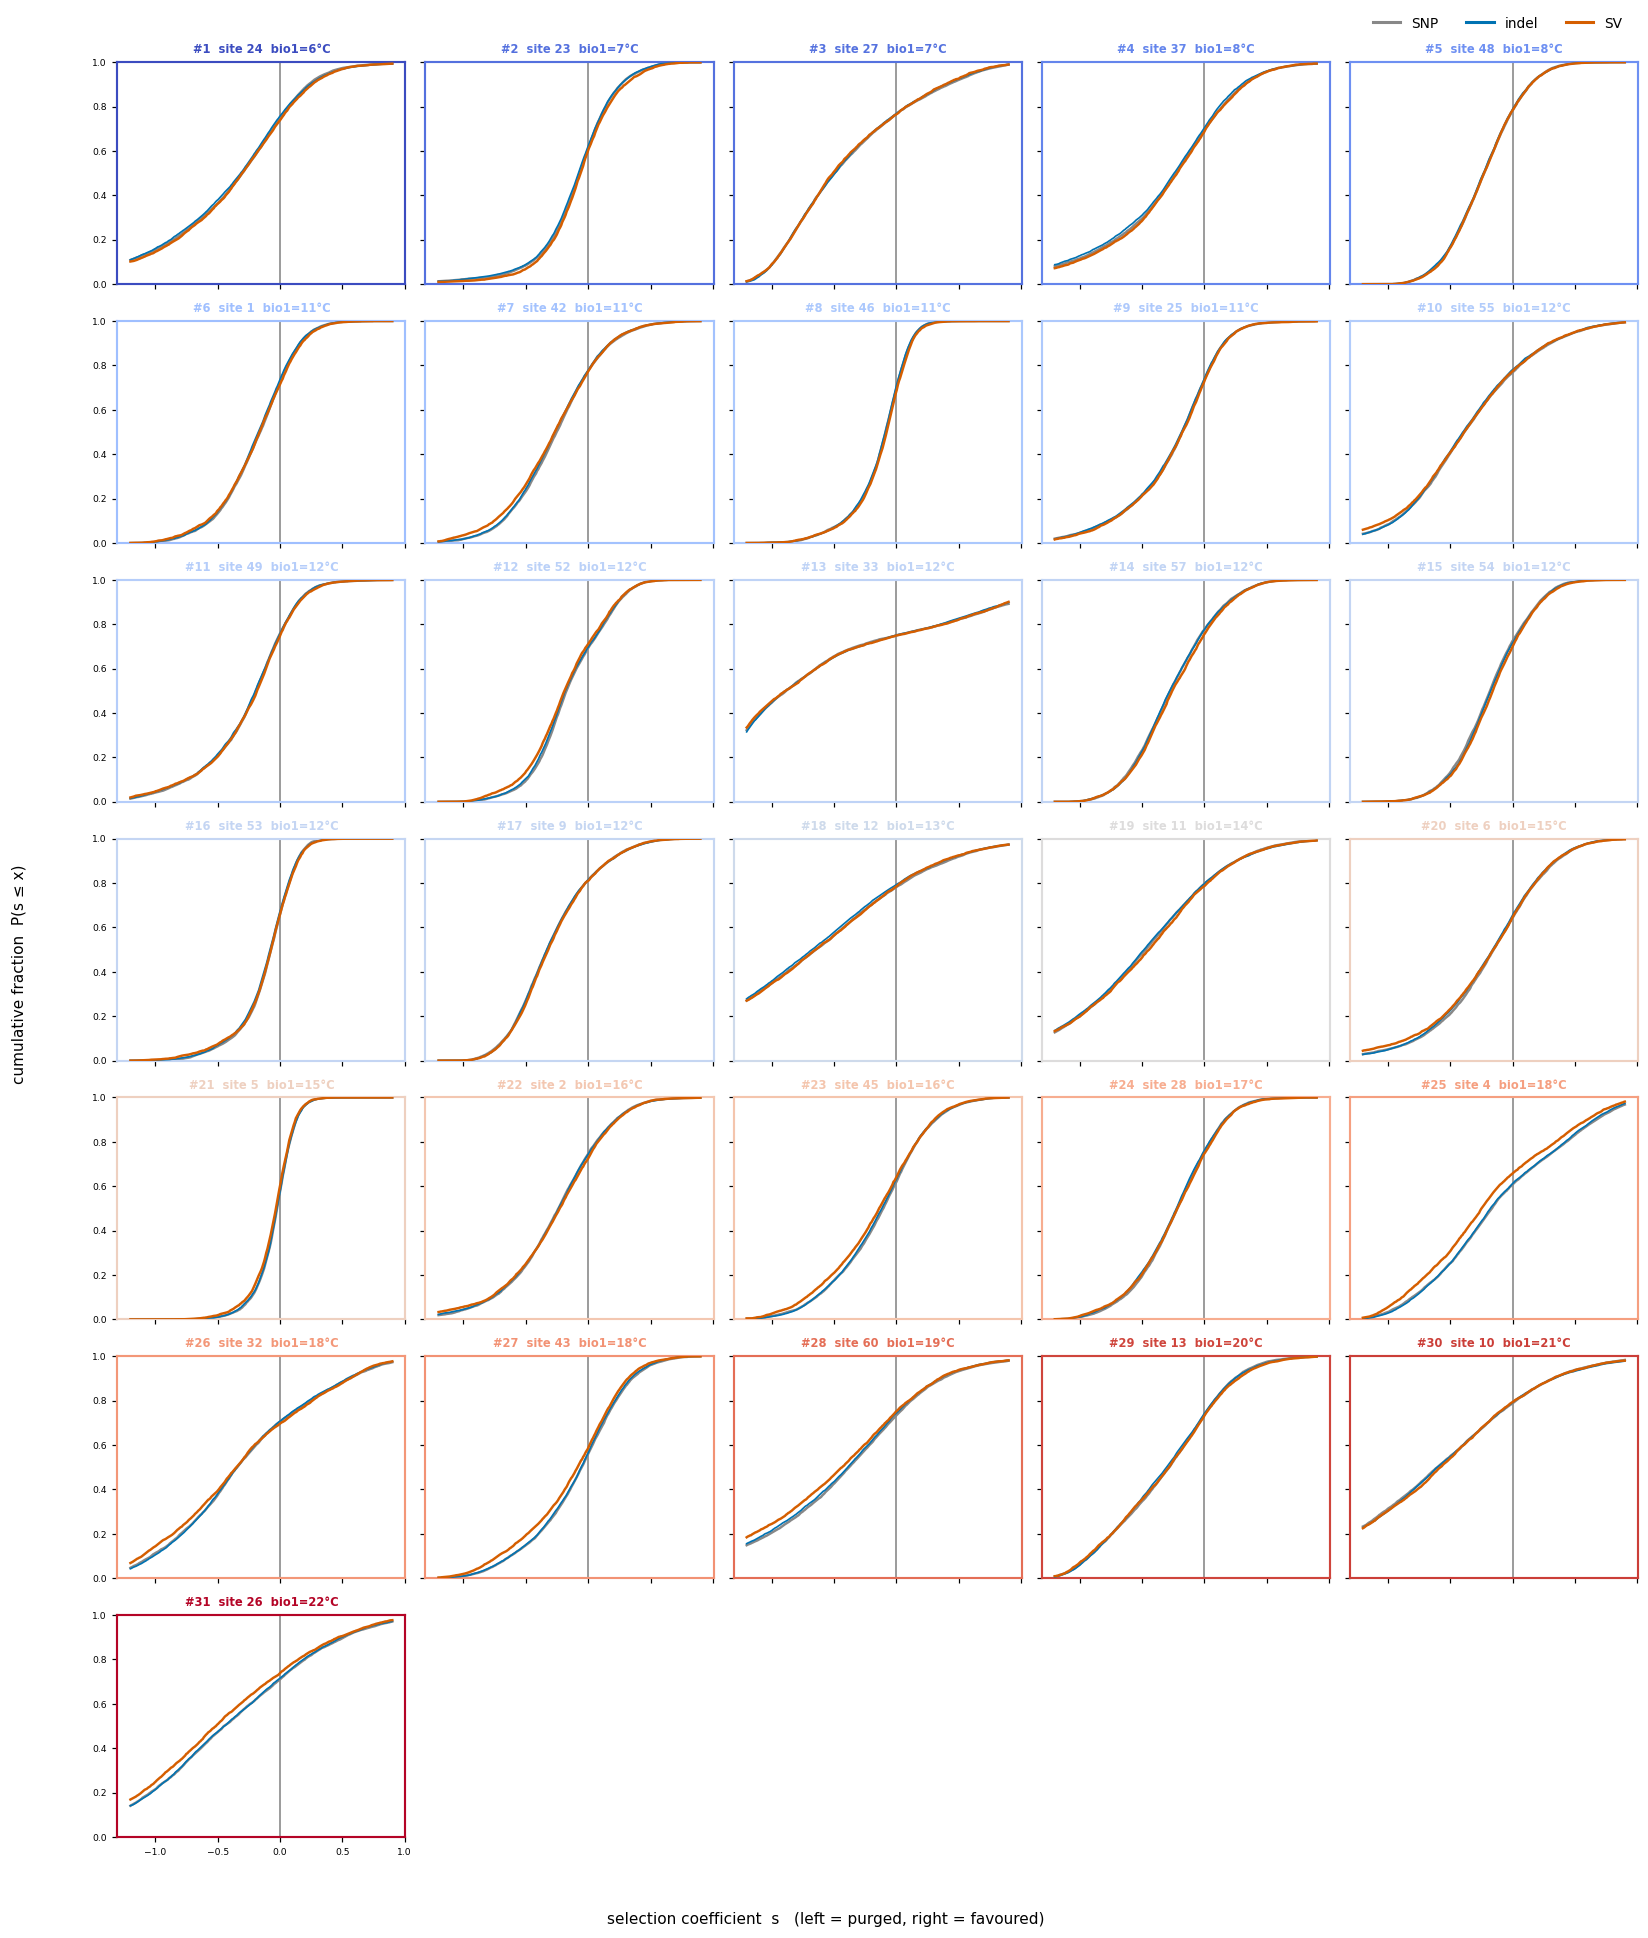

saved s_ecdf_by_site.png -- orange rising above grey/blue left of s=0 = more purged; gap grows at hot sites, ~absent at cold ones. SNP/indel coincide.


In [5]:

GRID_E = np.linspace(-1.2, 0.9, 240)
def ecdf(s): ss=np.sort(s); return np.searchsorted(ss, GRID_E, side="right")/ss.size

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
norm = mpl.colors.Normalize(vmin=meta.bio1.min(), vmax=meta.bio1.max()); cmap = mpl.cm.coolwarm
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; p_sv = npz[f"{s}_p0_SV"]
    e_sv = ecdf(npz[f"{s}_s_SV"])
    e_sn = ecdf(match_to(p_sv, npz[f"{s}_s_SNP"],   npz[f"{s}_p0_SNP"]))
    e_in = ecdf(match_to(p_sv, npz[f"{s}_s_indel"], npz[f"{s}_p0_indel"]))
    ax.axvline(0, color="0.5", lw=1.0, zorder=1)
    ax.plot(GRID_E, e_sn, color=COL["SNP"],   lw=1.6, zorder=2)
    ax.plot(GRID_E, e_in, color=COL["indel"], lw=1.1, zorder=3)
    ax.plot(GRID_E, e_sv, color=COL["SV"],    lw=1.6, zorder=4)
    b1 = meta[meta.site==s].bio1.iloc[0]; c = cmap(norm(b1))
    ax.set_title(f"#{i+1}  site {s}  bio1={b1:.0f}°C", fontsize=7.5, color=c, fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(c); sp.set_linewidth(1.4)
    ax.set_ylim(0,1); ax.tick_params(labelsize=6)
fig.supxlabel("selection coefficient  s   (left = purged, right = favoured)", y=0.005, fontsize=10)
fig.supylabel("cumulative fraction  P(s ≤ x)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.tight_layout(rect=[0.03,0.02,1,0.99])
fig.savefig(f"{G}/s_ecdf_by_site.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved s_ecdf_by_site.png -- orange rising above grey/blue left of s=0 = more purged; "
      "gap grows at hot sites, ~absent at cold ones. SNP/indel coincide.")


### 2c. ECDF-difference per site (the more sensitive companion to 2b)
$\Delta\mathrm{CDF}(x) = P(s_{\text{class}} \le x) - P(s_{\text{matched SNP}} \le x)$. Positive hump ⇒
left-shifted (more purged); peak height ≈ KS statistic.

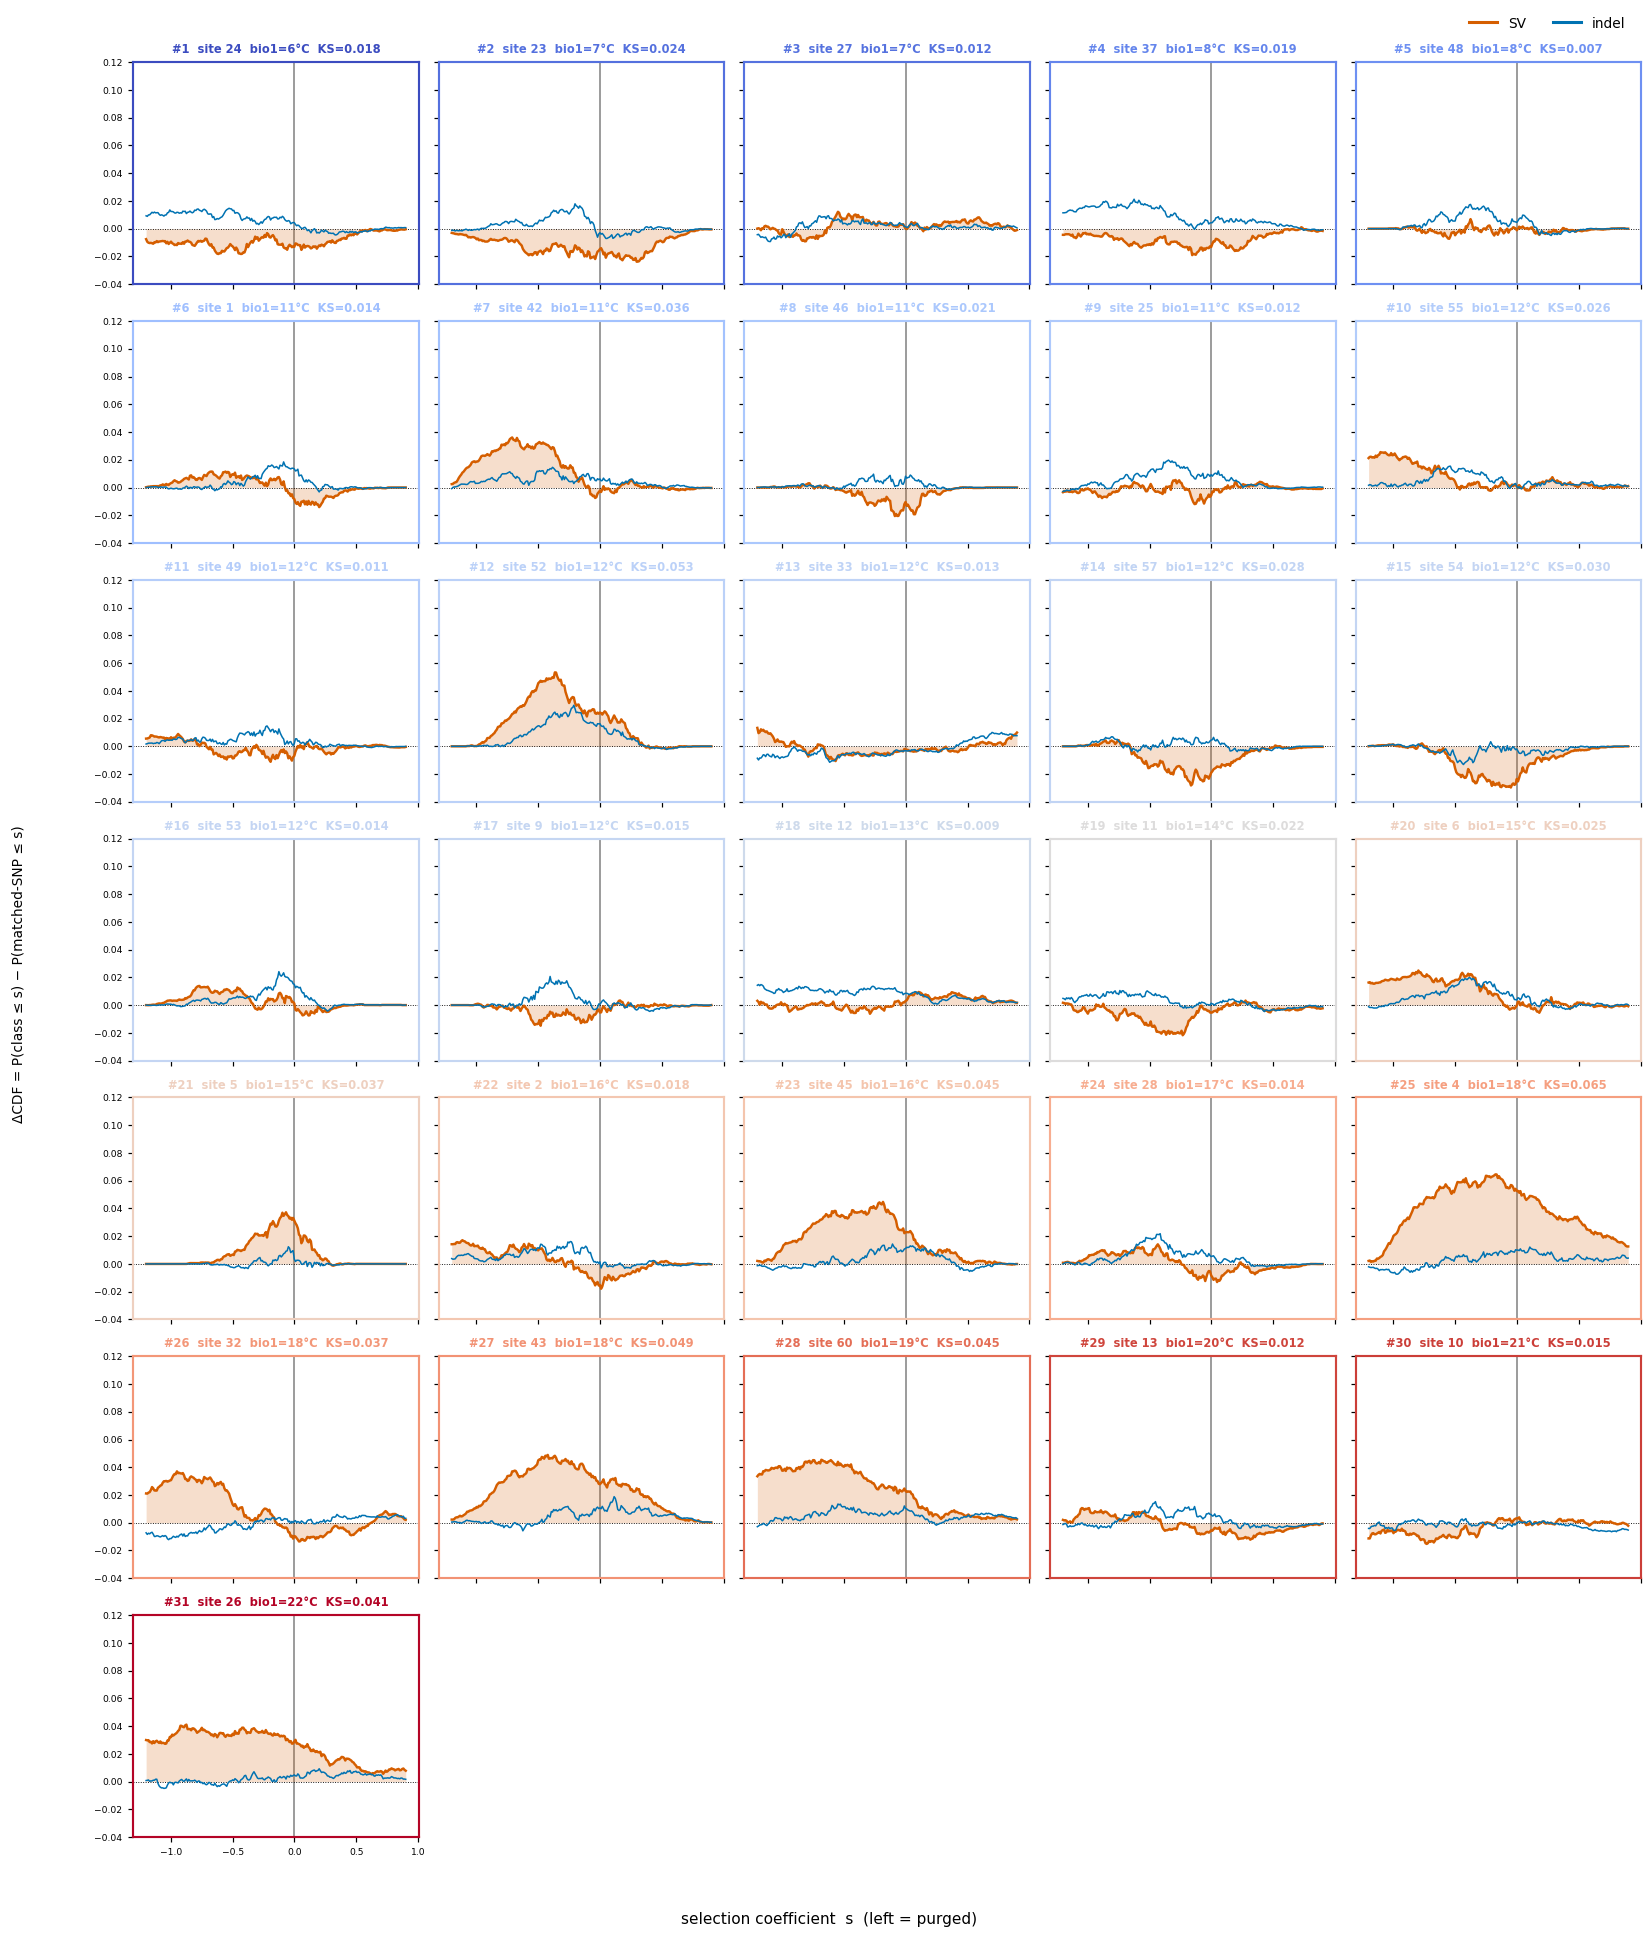

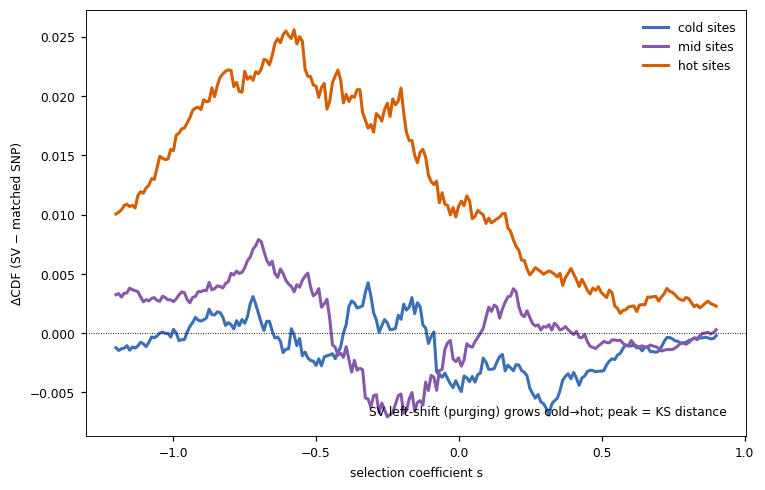

saved s_ecdf_difference_by_site.png + _summary.png


In [6]:

GRID_D = np.linspace(-1.2, 0.9, 220)
def cdf(s): ss=np.sort(s); return np.searchsorted(ss, GRID_D, side="right")/ss.size

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
norm = mpl.colors.Normalize(vmin=meta.bio1.min(), vmax=meta.bio1.max()); cmap = mpl.cm.coolwarm
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; p_sv = npz[f"{s}_p0_SV"]
    base = cdf(match_to(p_sv, npz[f"{s}_s_SNP"], npz[f"{s}_p0_SNP"]))
    dsv = cdf(npz[f"{s}_s_SV"]) - base
    din = cdf(match_to(p_sv, npz[f"{s}_s_indel"], npz[f"{s}_p0_indel"])) - base
    ax.axhline(0, color="k", lw=0.6, ls=":"); ax.axvline(0, color="0.5", lw=1.0, zorder=1)
    ax.fill_between(GRID_D, 0, dsv, color=COL["SV"], alpha=0.20, lw=0)
    ax.plot(GRID_D, dsv, color=COL["SV"], lw=1.6); ax.plot(GRID_D, din, color=COL["indel"], lw=1.0)
    b1 = meta[meta.site==s].bio1.iloc[0]; c = cmap(norm(b1))
    ax.set_title(f"#{i+1}  site {s}  bio1={b1:.0f}°C  KS={np.abs(dsv).max():.03f}",
                 fontsize=7.5, color=c, fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(c); sp.set_linewidth(1.4)
    ax.tick_params(labelsize=6)
axes[0].set_ylim(-0.04, 0.12)
fig.supxlabel("selection coefficient  s  (left = purged)", y=0.005, fontsize=10)
fig.supylabel("ΔCDF = P(class ≤ s) − P(matched-SNP ≤ s)", x=0.004, fontsize=9)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SV","indel"]],
           loc="upper right", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.tight_layout(rect=[0.03,0.02,1,0.99])
fig.savefig(f"{G}/s_ecdf_difference_by_site.png", dpi=130, bbox_inches="tight"); plt.show()

terc = pd.qcut(meta.bio1, 3, labels=["cold","mid","hot"])
tcol = {"cold":"#3B6FB6","mid":"#8858AA","hot":"#D55E00"}
fig, ax = plt.subplots(figsize=(7,4.5))
for t in ["cold","mid","hot"]:
    ss = meta.site[terc.values==t].tolist()
    sv=np.concatenate([npz[f"{s}_s_SV"] for s in ss]); psv=np.concatenate([npz[f"{s}_p0_SV"] for s in ss])
    m=match_to(psv, np.concatenate([npz[f"{s}_s_SNP"] for s in ss]),
                     np.concatenate([npz[f"{s}_p0_SNP"] for s in ss]))
    ax.plot(GRID_D, cdf(sv)-cdf(m), color=tcol[t], lw=2, label=f"{t} sites")
ax.axhline(0,color="k",lw=0.6,ls=":")
ax.set_xlabel("selection coefficient s"); ax.set_ylabel("ΔCDF (SV − matched SNP)")
ax.annotate("SV left-shift (purging) grows cold→hot; peak = KS distance", xy=(0.97,0.05),
            xycoords="axes fraction", ha="right", fontsize=8)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/s_ecdf_difference_summary.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved s_ecdf_difference_by_site.png + _summary.png")


### 2d. Shift function per site (Doksum) — shows exactly WHERE in the tail classes differ
$Q_{\text{class}}(\tau) - Q_{\text{matched SNP}}(\tau)$ vs percentile $\tau$, with a 90% bootstrap CI
on the SV shift. Flat at 0 ⇒ identical; dip below 0 at low $\tau$ ⇒ heavier purged tail.

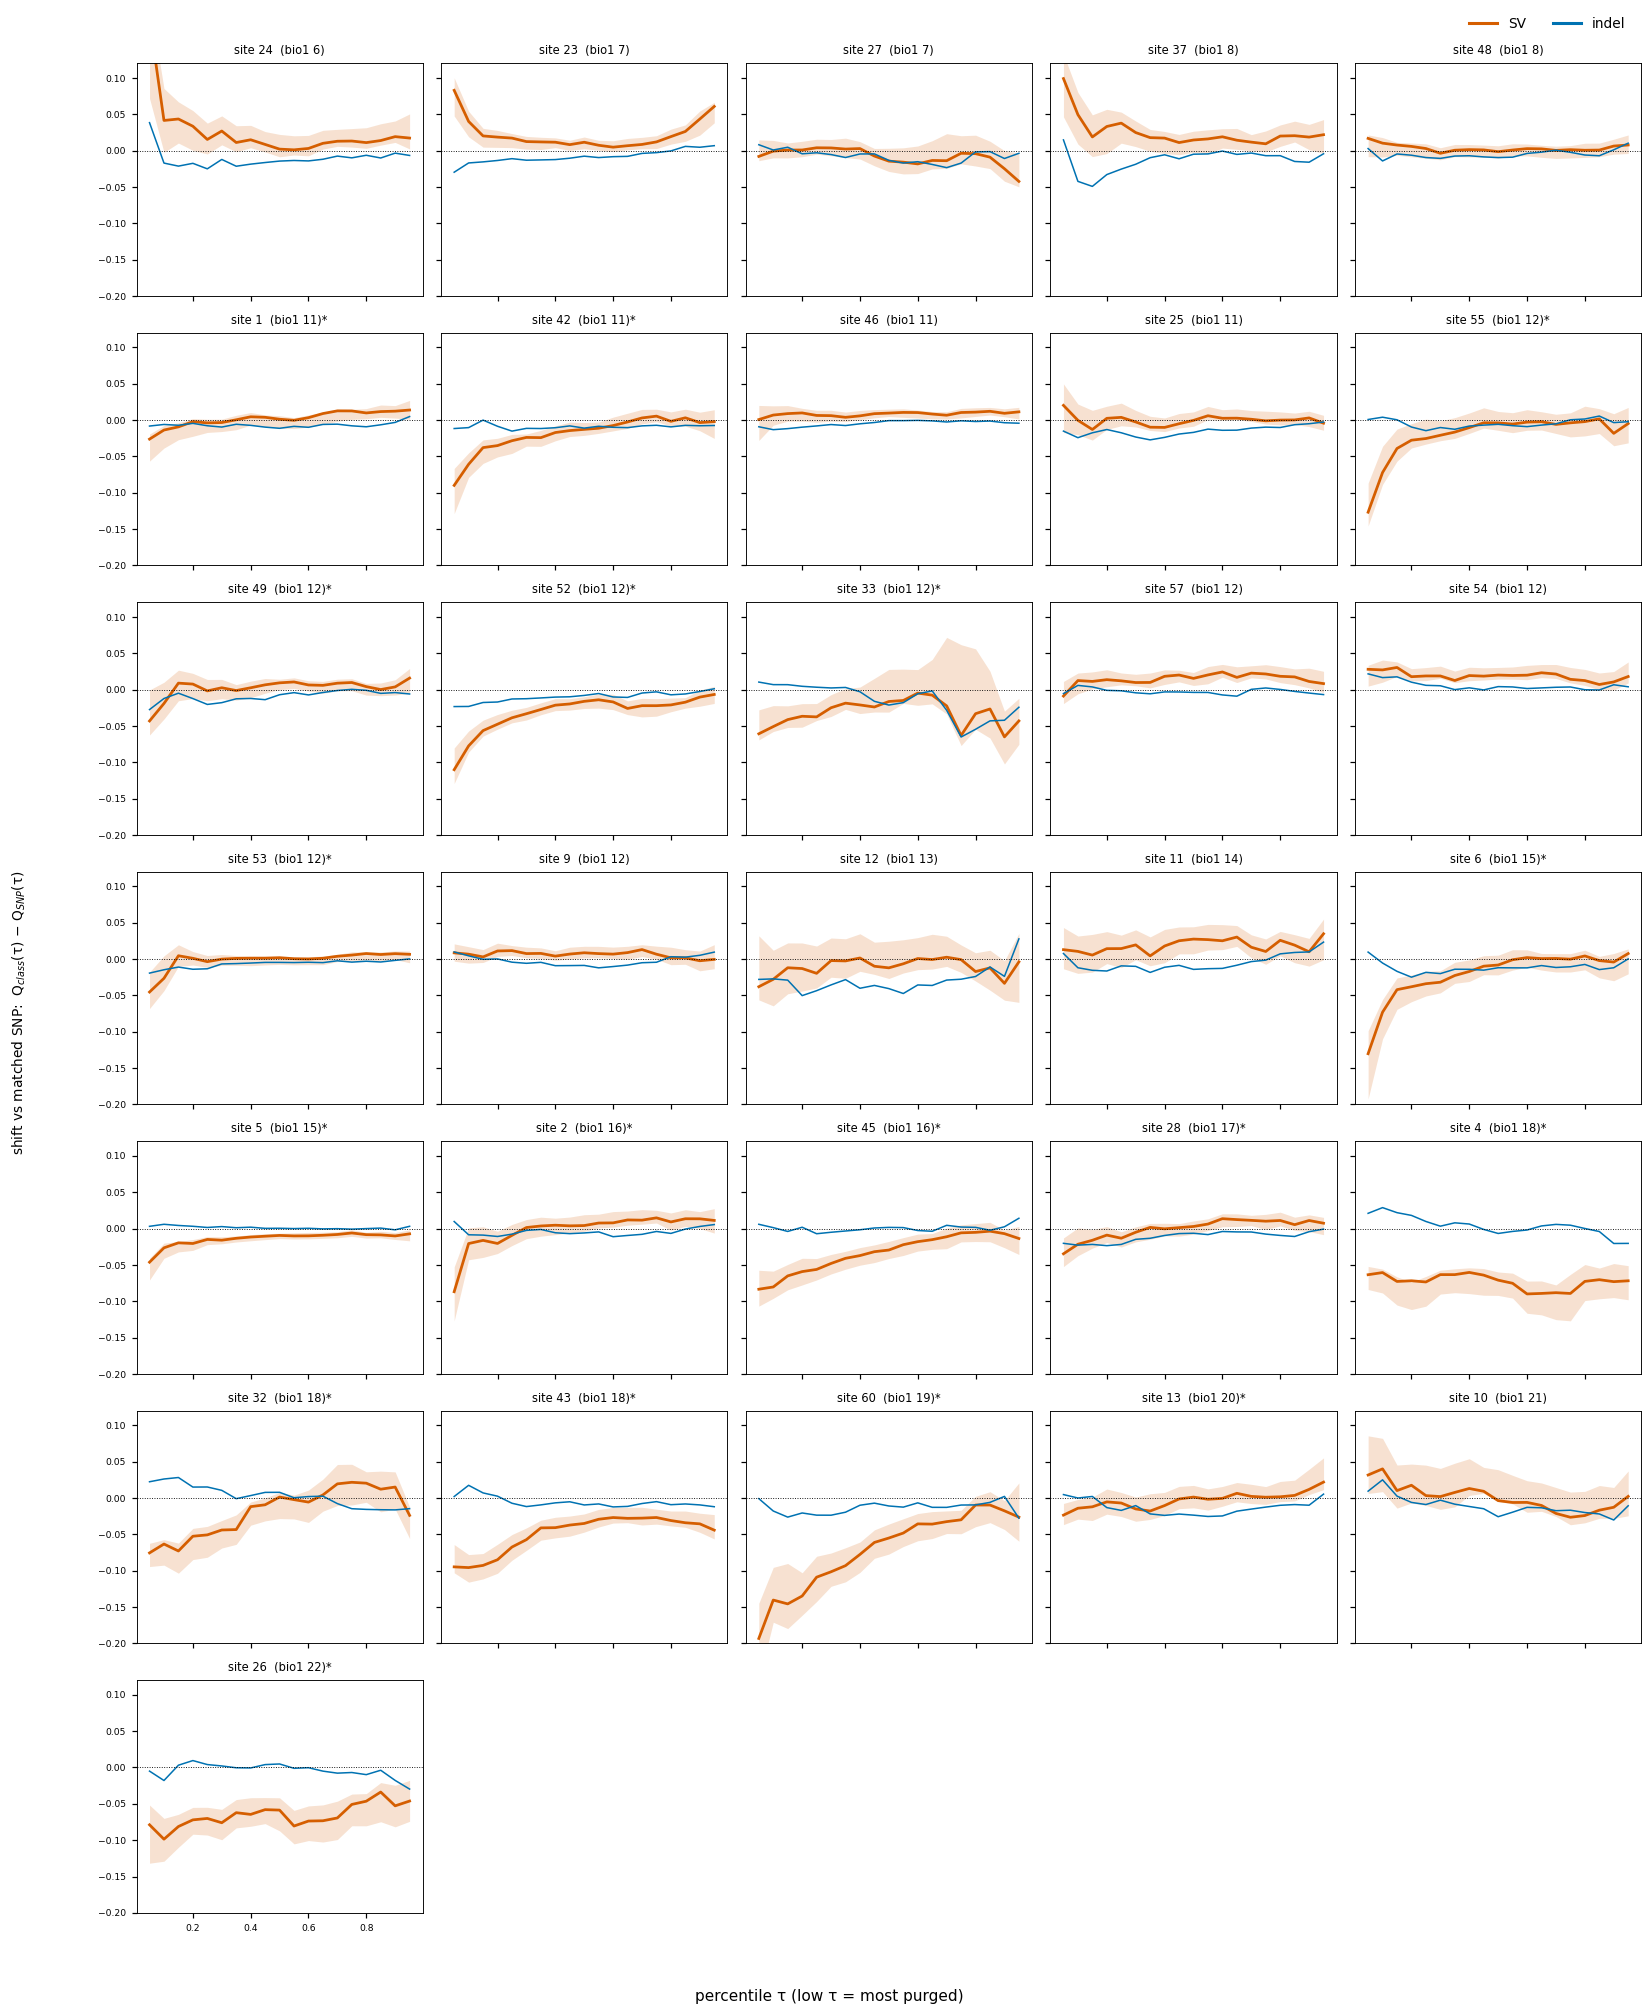

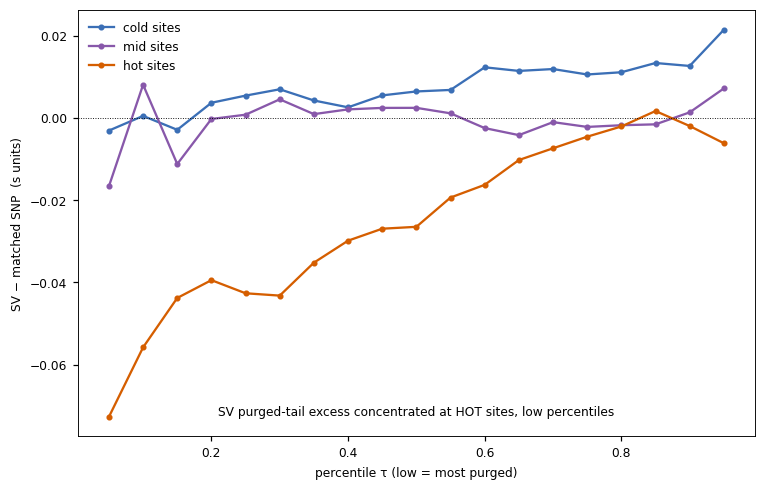

saved s_shiftfunction_by_site.png + _summary.png  (* = 90% bootstrap band excludes 0 in lower tail)


In [7]:

TAUS = np.linspace(0.05, 0.95, 19); NBOOT = 300

def shift_and_band(site):
    sv=npz[f"{site}_s_SV"]; p_sv=npz[f"{site}_p0_SV"]
    sn=npz[f"{site}_s_SNP"]; p_sn=npz[f"{site}_p0_SNP"]
    ind=npz[f"{site}_s_indel"]; p_in=npz[f"{site}_p0_indel"]
    msn = match_to(p_sv, sn, p_sn); min_ = match_to(p_sv, ind, p_in)
    base = np.quantile(msn, TAUS)
    sh_sv  = np.quantile(sv, TAUS)  - base
    sh_ind = np.quantile(min_, TAUS) - base
    boot=np.empty((NBOOT, TAUS.size))
    for b in range(NBOOT):
        idx = rng.integers(0, sv.size, sv.size)
        m = match_to(p_sv[idx], sn, p_sn)
        boot[b] = np.quantile(sv[idx], TAUS) - np.quantile(m, TAUS)
    lo, hi = np.percentile(boot, [5,95], axis=0)
    return sh_sv, sh_ind, lo, hi

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.6*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]
    sh_sv, sh_ind, lo, hi = shift_and_band(s)
    ax.fill_between(TAUS, lo, hi, color=COL["SV"], alpha=0.18, lw=0)
    ax.plot(TAUS, sh_sv,  "-", color=COL["SV"],  lw=1.8, label="SV")
    ax.plot(TAUS, sh_ind, "-", color=COL["indel"], lw=1.0, label="indel")
    ax.axhline(0, color="k", lw=0.6, ls=":")
    b1 = meta[meta.site==s].bio1.iloc[0]
    sig = "*" if (hi[:6] < 0).any() else ""
    ax.set_title(f"site {s}  (bio1 {b1:.0f}){sig}", fontsize=7.5)
    ax.tick_params(labelsize=6)
axes[0].set_ylim(-0.20, 0.12)
fig.supxlabel("percentile τ (low τ = most purged)", y=0.005, fontsize=10)
fig.supylabel("shift vs matched SNP:  Q$_{class}$(τ) − Q$_{SNP}$(τ)", x=0.004, fontsize=9)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SV","indel"]],
           loc="upper right", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.tight_layout(rect=[0.03,0.02,1,0.99])
fig.savefig(f"{G}/s_shiftfunction_by_site.png", dpi=130, bbox_inches="tight"); plt.show()

terc = pd.qcut(meta.bio1, 3, labels=["cold","mid","hot"])
tcol = {"cold":"#3B6FB6","mid":"#8858AA","hot":"#D55E00"}
fig, ax = plt.subplots(figsize=(7,4.5))
for t in ["cold","mid","hot"]:
    ss = meta.site[terc.values==t].tolist()
    sv = np.concatenate([npz[f"{s}_s_SV"] for s in ss]); p_sv=np.concatenate([npz[f"{s}_p0_SV"] for s in ss])
    sn = np.concatenate([npz[f"{s}_s_SNP"] for s in ss]); p_sn=np.concatenate([npz[f"{s}_p0_SNP"] for s in ss])
    m = match_to(p_sv, sn, p_sn)
    ax.plot(TAUS, np.quantile(sv,TAUS)-np.quantile(m,TAUS), "-o", color=tcol[t], ms=3, label=f"{t} sites")
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("percentile τ (low = most purged)"); ax.set_ylabel("SV − matched SNP  (s units)")
ax.annotate("SV purged-tail excess concentrated at HOT sites, low percentiles", xy=(0.5,0.05),
            xycoords="axes fraction", ha="center", fontsize=8)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/s_shiftfunction_summary.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved s_shiftfunction_by_site.png + _summary.png  (* = 90% bootstrap band excludes 0 in lower tail)")


### 2e. SV−SNP difference vs climate, one point per site (independent axis)
Puts selection (frequency-matched SV−SNP difference) on y and site climate (independent of
selection) on x.

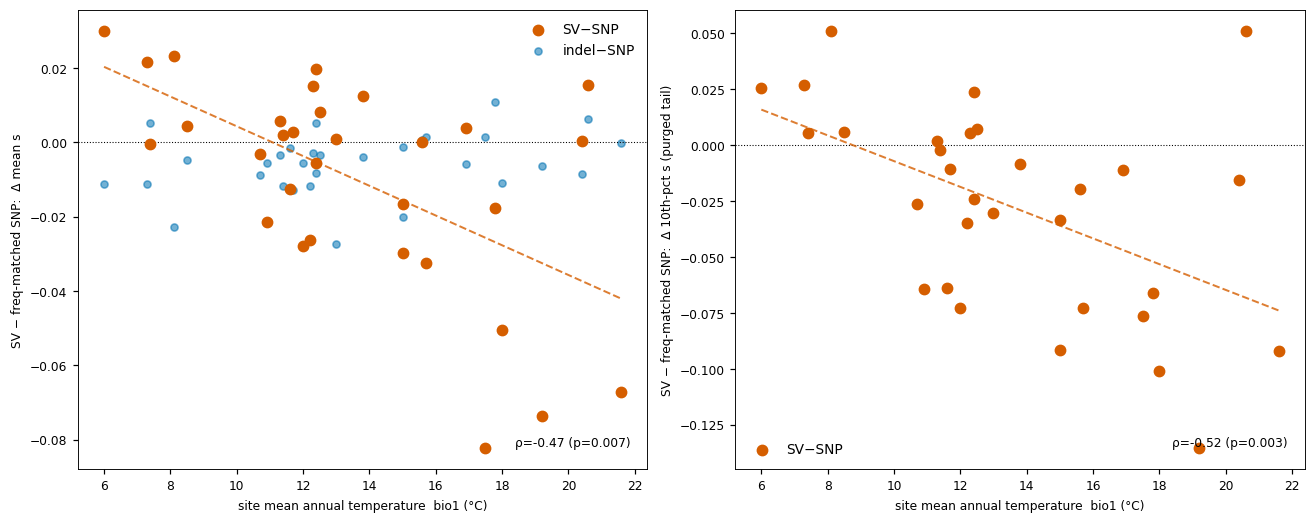

purged-tail (10th pct) SV<SNP at hot sites (bio1>=15): 11/12
mean-s difference: median across sites -0.0000; indel-SNP median -0.0056 (~0)


In [8]:

rows=[]
for s in meta.site:
    sv=npz[f"{s}_s_SV"]; p_sv=npz[f"{s}_p0_SV"]
    msn=match_to(p_sv, npz[f"{s}_s_SNP"], npz[f"{s}_p0_SNP"])
    mind=match_to(p_sv, npz[f"{s}_s_indel"], npz[f"{s}_p0_indel"])
    rows.append(dict(site=s, bio1=meta[meta.site==s].bio1.iloc[0],
        d_mean=sv.mean()-msn.mean(), d_p10=np.quantile(sv,.10)-np.quantile(msn,.10),
        ind_mean=mind.mean()-msn.mean()))
d=pd.DataFrame(rows)

fig, ax = plt.subplots(1,2, figsize=(12,4.8))
for a,(col,lab) in zip(ax, [("d_mean","mean s"),("d_p10","10th-pct s (purged tail)")]):
    a.axhline(0,color="k",lw=0.7,ls=":")
    a.scatter(d.bio1, d[col], c="#D55E00", s=45, zorder=3, label="SV−SNP")
    if col=="d_mean":
        a.scatter(d.bio1, d.ind_mean, c="#0072B2", s=22, alpha=.55, label="indel−SNP")
    r=stats.spearmanr(d.bio1, d[col])
    b,a0=np.polyfit(d.bio1, d[col],1); xs=np.array([d.bio1.min(),d.bio1.max()])
    a.plot(xs, a0+b*xs, color="#D55E00", lw=1.3, ls="--", alpha=.8)
    a.set_xlabel("site mean annual temperature  bio1 (°C)"); a.set_ylabel(f"SV − freq-matched SNP:  Δ {lab}")
    a.annotate(f"ρ={r.statistic:+.2f} (p={r.pvalue:.3f})", xy=(0.97,0.05), xycoords="axes fraction",
               ha="right", fontsize=8)
    a.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(f"{G}/s_vs_climate.png", dpi=130, bbox_inches="tight"); plt.show()
nneg_hot=int(((d.bio1>=15)&(d.d_p10<0)).sum()); nhot=int((d.bio1>=15).sum())
print(f"purged-tail (10th pct) SV<SNP at hot sites (bio1>=15): {nneg_hot}/{nhot}")
print(f"mean-s difference: median across sites {d.d_mean.median():+.4f}; indel-SNP median {d.ind_mean.median():+.4f} (~0)")


**Section 2 takeaway (verified real):** indel ≈ SNP everywhere, in every view. **SV has a heavier
purged tail than frequency-matched SNP, concentrated at hot/arid sites** — not a whole-distribution
shift (Section 1 is right about that), but a real, modest, climate-concentrated tail effect,
insertion-driven. Five independent statistics agree. This was previously (wrongly) dismissed as
sharing Section 1's confound — Section 4 tests that directly.

## Section 3 — climate-slope β (VERIFIED REAL)

$\beta_v = d\,s_v / d\,\text{climate}$ per variant, across sites (removes a constant per-variant
hitchhiking/artifact offset — only shows up if purging *intensifies* with climate). Two axes: bio1
(temperature) and bio18 (precipitation of the warmest quarter; low = arid summer).

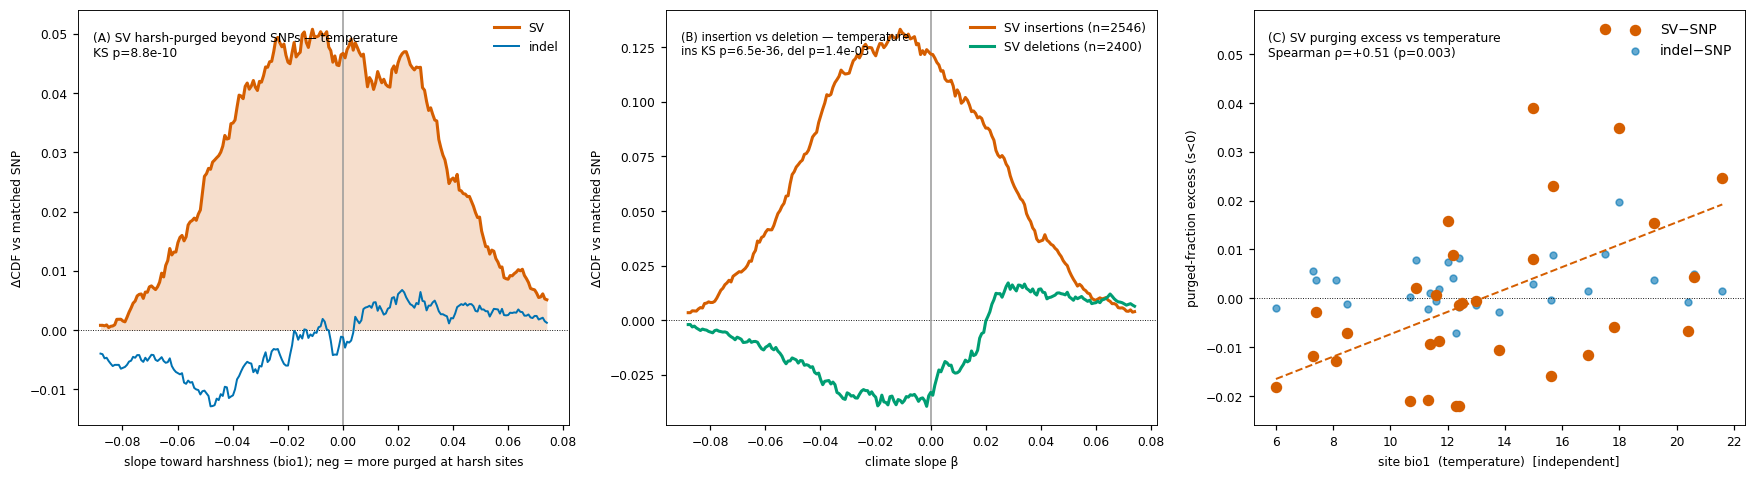

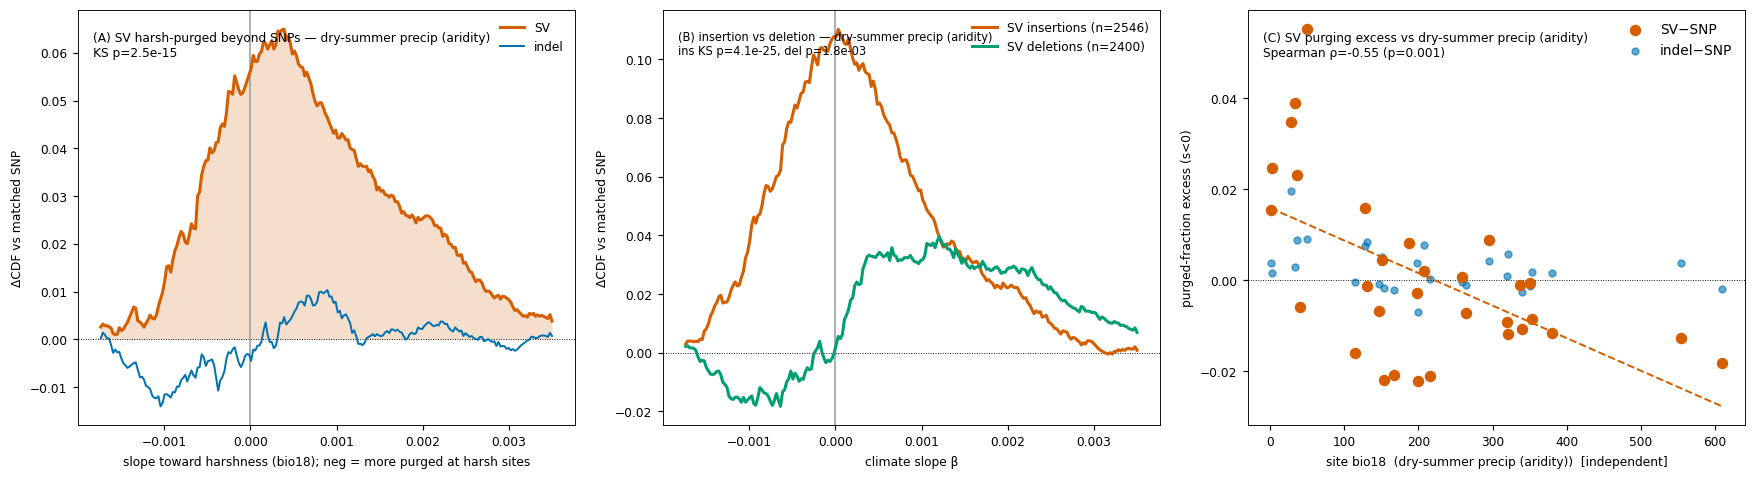

In [9]:

z = np.load(f"{G}/s_climate_slope.npz")
sign = pd.read_csv(f"{G}/s_climate_slope_sign_by_site.csv")

def make(cvar, label, sign_sign):
    bsv=sign_sign*z[f"beta_sv_{cvar}"]; bind=sign_sign*z[f"beta_indel_{cvar}"]; bsn=sign_sign*z[f"beta_snp_{cvar}"]
    msnp=match_to(z["p0_sv"],bsn,z["p0_snp"]); mind=match_to(z["p0_sv"],bind,z["p0_indel"])
    lo,hi=np.percentile(np.concatenate([bsv,msnp]),[1,99]); grid=np.linspace(lo,hi,220)
    cdf=lambda s:(np.searchsorted(np.sort(s),grid,side="right")/s.size)
    base=cdf(msnp)
    fig,ax=plt.subplots(1,3,figsize=(16,4.4))
    ax[0].axhline(0,color="k",lw=.6,ls=":"); ax[0].axvline(0,color="0.6",lw=1)
    ax[0].fill_between(grid,0,cdf(bsv)-base,color=COL["SV"],alpha=.2,lw=0)
    ax[0].plot(grid,cdf(bsv)-base,color=COL["SV"],lw=2,label="SV")
    ax[0].plot(grid,cdf(mind)-base,color=COL["indel"],lw=1.3,label="indel")
    ax[0].set_xlabel(f"slope toward harshness ({cvar}); neg = more purged at harsh sites"); ax[0].set_ylabel("ΔCDF vs matched SNP")
    ax[0].annotate(f"(A) SV harsh-purged beyond SNPs — {label}\nKS p={stats.ks_2samp(bsv,msnp).pvalue:.1e}",
                   xy=(0.03,0.95), xycoords="axes fraction", va="top", fontsize=8)
    ax[0].legend(frameon=False)
    ins=bsv[~z["sv_isdel"]]; dele=bsv[z["sv_isdel"]]
    ax[1].axhline(0,color="k",lw=.6,ls=":"); ax[1].axvline(0,color="0.6",lw=1)
    ax[1].plot(grid,cdf(ins)-base,color=COL["ins"],lw=2,label=f"SV insertions (n={ins.size})")
    ax[1].plot(grid,cdf(dele)-base,color=COL["del"],lw=2,label=f"SV deletions (n={dele.size})")
    ax[1].set_xlabel("climate slope β"); ax[1].set_ylabel("ΔCDF vs matched SNP")
    ax[1].annotate(f"(B) insertion vs deletion — {label}\nins KS p={stats.ks_2samp(ins,msnp).pvalue:.1e}, "
                   f"del p={stats.ks_2samp(dele,msnp).pvalue:.1e}", xy=(0.03,0.95), xycoords="axes fraction",
                   va="top", fontsize=7.5)
    ax[1].legend(frameon=False,fontsize=8)
    d=sign.copy(); d["excess"]=d.sv_neg-d.msnp_neg
    r=stats.spearmanr(d[cvar],d.excess)
    ax[2].axhline(0,color="k",lw=.6,ls=":")
    ax[2].scatter(d[cvar],d.excess,c=COL["SV"],s=42,zorder=3,label="SV−SNP")
    ax[2].scatter(d[cvar],d.mindel_neg-d.msnp_neg,c=COL["indel"],s=20,alpha=.6,label="indel−SNP")
    b,a0=np.polyfit(d[cvar],d.excess,1); xs=np.array([d[cvar].min(),d[cvar].max()])
    ax[2].plot(xs,a0+b*xs,color=COL["SV"],ls="--",lw=1.3)
    ax[2].set_xlabel(f"site {cvar}  ({label})  [independent]"); ax[2].set_ylabel("purged-fraction excess (s<0)")
    ax[2].annotate(f"(C) SV purging excess vs {label}\nSpearman ρ={r.statistic:+.2f} (p={r.pvalue:.3f})",
                   xy=(0.03,0.95), xycoords="axes fraction", va="top", fontsize=8)
    ax[2].legend(frameon=False,fontsize=9)
    fig.tight_layout(); fig.savefig(f"{G}/s_climate_slope_{cvar}.png",dpi=130,bbox_inches="tight"); plt.show()

make("bio1","temperature",+1)
make("bio18","dry-summer precip (aridity)",-1)


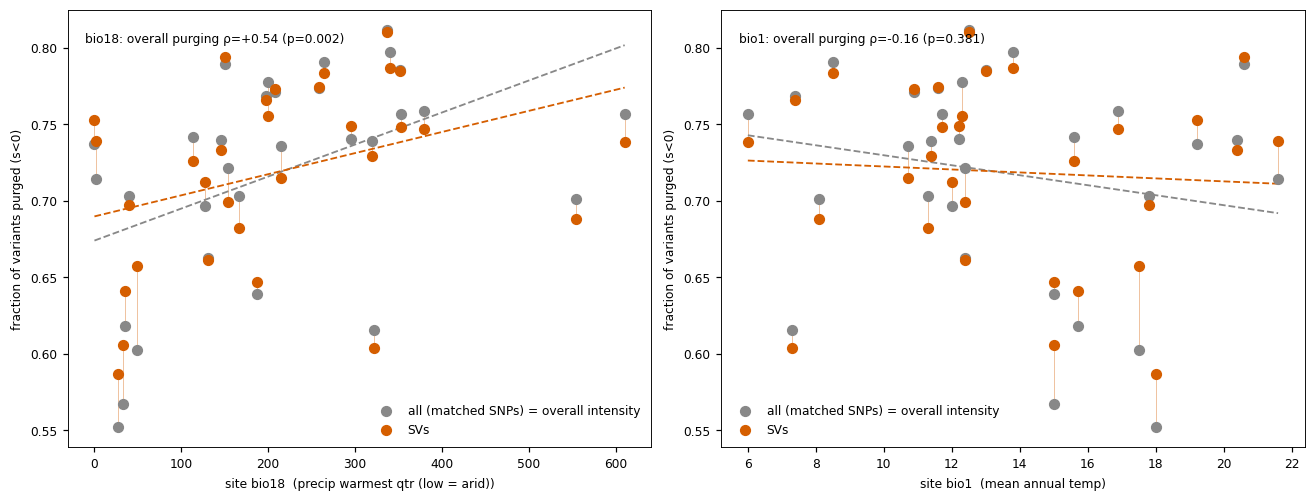

overall intensity (matched SNP purged frac, NOT the SV-specific number): range 0.55-0.81
corr(intensity, bio18)=+0.54  corr(intensity, bio1)=-0.16  -- general 'harsh sites purge more' effect, differenced out in the SV-SNP excess above
[the actual SV-specific finding] sign-excess (sv_neg-msnp_neg) vs bio1: rho=+0.509 p=0.0035
[the actual SV-specific finding] sign-excess (sv_neg-msnp_neg) vs bio18: rho=-0.552 p=0.0013


In [10]:

# OVERALL PURGING INTENSITY vs climate -- a confound check, NOT the SV-specific finding
# (this is the statistic that was mislabeled as "the climate-slope β result" in an earlier audit
# pass -- keep it clearly separate from sign.excess/beta above)
d=sign.copy()
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
for a,(cv,lab) in zip(ax,[("bio18","precip warmest qtr (low = arid)"),("bio1","mean annual temp")]):
    a.scatter(d[cv],d.msnp_neg,c="#888888",s=40,zorder=3,label="all (matched SNPs) = overall intensity")
    a.scatter(d[cv],d.sv_neg,c="#D55E00",s=40,zorder=3,label="SVs")
    for x,lo,hi in zip(d[cv],d.msnp_neg,d.sv_neg):
        a.plot([x,x],[lo,hi],color="#D55E00",lw=0.6,alpha=0.4,zorder=2)
    for cc,col in [("msnp_neg","#888888"),("sv_neg","#D55E00")]:
        b,a0=np.polyfit(d[cv],d[cc],1); xs=np.array([d[cv].min(),d[cv].max()]); a.plot(xs,a0+b*xs,color=col,ls="--",lw=1.2)
    r=stats.spearmanr(d[cv],d.msnp_neg)
    a.set_xlabel(f"site {cv}  ({lab})"); a.set_ylabel("fraction of variants purged (s<0)")
    a.annotate(f"{cv}: overall purging ρ={r.statistic:+.2f} (p={r.pvalue:.3f})", xy=(0.03,0.95),
               xycoords="axes fraction", va="top", fontsize=8)
    a.legend(frameon=False,fontsize=8)
fig.tight_layout(); fig.savefig(f"{G}/s_purging_intensity.png",dpi=130,bbox_inches="tight"); plt.show()
print(f"overall intensity (matched SNP purged frac, NOT the SV-specific number): "
      f"range {d.msnp_neg.min():.2f}-{d.msnp_neg.max():.2f}")
print(f"corr(intensity, bio18)={stats.spearmanr(d.bio18,d.msnp_neg).statistic:+.2f}  "
      f"corr(intensity, bio1)={stats.spearmanr(d.bio1,d.msnp_neg).statistic:+.2f}  "
      f"-- general 'harsh sites purge more' effect, differenced out in the SV-SNP excess above")
d["excess"]=d.sv_neg-d.msnp_neg
for cv in ["bio1","bio18"]:
    r = stats.spearmanr(d[cv], d.excess)
    print(f"[the actual SV-specific finding] sign-excess (sv_neg-msnp_neg) vs {cv}: "
          f"rho={r.statistic:+.3f} p={r.pvalue:.4f}")


**Section 3 takeaway (verified real):** the SV climate-purging hump and insertion-only split hold
on both axes; aridity (bio18) is the stronger correlate. The general "harsh sites purge everything
more" effect is real (grey curve rises toward harsh sites) but does **not** explain the SV-specific
excess (the grey→orange gap is a within-site difference our test isolates, and it doesn't scale with
overall intensity). **Do not confuse the general-intensity correlation with the SV-specific
sign-excess correlation printed at the end of the cell above** — an earlier audit pass mixed these up
and wrongly concluded this arm had weakened.

## Section 4 — direct de-trending audit (2026-07-15): does Section 1's fix kill Sections 2-3?

Section 1's de-trending (subtract the per-p0-bin ALL-class-pooled median `s`) killed the
whole-distribution median-shift signal. An earlier pass assumed, by analogy, that Sections 2-3's
tail/climate signal shared the same confound and would also die under the same correction — that was
never tested directly until now. This section applies the identical correction to (a) climate-slope
β's sign-excess and (b) a direct 10th-percentile tail-gap, hot vs cold sites.

In [11]:

sites_hot_cold = sorted({int(k.split("_")[0]) for k in npz.files if k.split("_")[0].isdigit()})
clim_site = meta.set_index("site")["bio1"]

def resid_frac_neg(site):
    # de-trended fraction s<0: s minus the per-(site,stratum) ALL-class median baseline
    s_sv, p0_sv = npz[f"{site}_s_SV"].astype(np.float64), npz[f"{site}_p0_SV"].astype(np.float64)
    s_sn, p0_sn = npz[f"{site}_s_SNP"].astype(np.float64), npz[f"{site}_p0_SNP"].astype(np.float64)
    b_sv, b_sn = binf(p0_sv), binf(p0_sn)
    base_sv = np.array([base_lookup.get((site, b), np.nan) for b in b_sv])
    base_sn = np.array([base_lookup.get((site, b), np.nan) for b in b_sn])
    r_sv, r_sn = s_sv - base_sv, s_sn - base_sn
    k_sv, k_sn = np.isfinite(r_sv), np.isfinite(r_sn)
    return (s_sv, p0_sv, s_sn, p0_sn, r_sv[k_sv], p0_sv[k_sv], r_sn[k_sn], p0_sn[k_sn])

rows_raw, rows_resid, rows_tail_raw, rows_tail_resid = [], [], [], []
for site in sites_hot_cold:
    if site not in clim_site.index: continue
    s_sv, p0_sv, s_sn, p0_sn, r_sv, p0_svk, r_sn, p0_snk = resid_frac_neg(site)
    if s_sv.size < 20 or s_sn.size < 20: continue
    b1 = clim_site.loc[site]
    # (a) sign-excess, raw vs de-trended
    m_sn_raw = match_to(p0_sv, s_sn, p0_sn)
    m_sn_resid = match_to(p0_svk, r_sn, p0_snk)
    rows_raw.append(dict(site=site, bio1=b1, sv=(s_sv<0).mean(), msnp=(m_sn_raw<0).mean()))
    rows_resid.append(dict(site=site, bio1=b1, sv=(r_sv<0).mean(), msnp=(m_sn_resid<0).mean()))
    # (b) 10th-percentile tail gap, raw vs de-trended
    rows_tail_raw.append(dict(site=site, bio1=b1,
        gap=np.quantile(s_sv,0.10)-np.quantile(m_sn_raw,0.10)))
    rows_tail_resid.append(dict(site=site, bio1=b1,
        gap=np.quantile(r_sv,0.10)-np.quantile(m_sn_resid,0.10)))

print("=== (a) climate-slope sign-excess: RAW vs DE-TRENDED ===")
for label, rows in [("RAW", rows_raw), ("DE-TRENDED", rows_resid)]:
    d = pd.DataFrame(rows); d["excess"] = d.sv - d.msnp
    for cv in ["bio1"]:
        r = stats.spearmanr(d[cv], d.excess)
        print(f"  {label:11s} {cv}: rho={r.statistic:+.3f} p={r.pvalue:.4f}  "
              f"median excess={d.excess.median():+.4f}  {(d.excess>0).sum()}/{len(d)} sites positive")

print()
print("=== (b) 10th-pct tail gap (SV - matched SNP), hot (bio1>=15) vs cold: RAW vs DE-TRENDED ===")
for label, rows in [("RAW", rows_tail_raw), ("DE-TRENDED", rows_tail_resid)]:
    d = pd.DataFrame(rows)
    hot, cold = d[d.bio1>=15], d[d.bio1<15]
    r = stats.spearmanr(d.bio1, d.gap)
    print(f"  {label:11s} hot median={hot.gap.median():+.4f}  cold median={cold.gap.median():+.4f}  "
          f"vs bio1: rho={r.statistic:+.3f} p={r.pvalue:.4f}")

print()
print("CONCLUSION: both (a) and (b) barely move (if anything strengthen) between RAW and DE-TRENDED --")
print("the OPPOSITE of what removing a real p0-driven artifact should look like. The tail/hot-site")
print("signal in Sections 2-3 is NOT the confound that nulled Section 1's whole-distribution median.")


=== (a) climate-slope sign-excess: RAW vs DE-TRENDED ===
  RAW         bio1: rho=+0.429 p=0.0160  median excess=-0.0041  13/31 sites positive
  DE-TRENDED  bio1: rho=+0.417 p=0.0197  median excess=+0.0007  17/31 sites positive

=== (b) 10th-pct tail gap (SV - matched SNP), hot (bio1>=15) vs cold: RAW vs DE-TRENDED ===
  RAW         hot median=-0.0756  cold median=+0.0016  vs bio1: rho=-0.505 p=0.0037
  DE-TRENDED  hot median=-0.0515  cold median=+0.0011  vs bio1: rho=-0.516 p=0.0030

CONCLUSION: both (a) and (b) barely move (if anything strengthen) between RAW and DE-TRENDED --
the OPPOSITE of what removing a real p0-driven artifact should look like. The tail/hot-site
signal in Sections 2-3 is NOT the confound that nulled Section 1's whole-distribution median.


**Section 4 takeaway:** the tail/climate signal in Sections 2-3 survives the identical
de-trending correction that nulled Section 1's median-shift metric — both the sign-excess correlation
and the direct percentile-tail-gap test are essentially unchanged (if anything slightly stronger)
after de-trending. **This is a genuinely different, currently-unexplained signal, not the artifact
that explains Section 1's null.** It is still bounded by the standing hitchhiking and
insertion-polarity caveats (intro) — this section rules out one specific artifact explanation, not
all of them.

## Overall synthesis

| Question | Statistic | Verdict |
|---|---|---|
| Whole-distribution median shift | de-trended `s` (Section 1) | **NULL** |
| Tail-specific, hot-site purging | histogram/ECDF/ECDF-diff/shift-fn/vs-climate (Section 2) | **REAL** |
| Climate-slope β | regression slope of `s` on climate (Section 3) | **REAL** |
| Does de-trending kill the tail/climate signal? | direct test (Section 4) | **No — survives** |

**Bottom line:** there is no genome-wide, frequency-independent shift in SV selection behavior, but
there is a real, modest, insertion-driven excess of SV purging concentrated in the tail at hot/arid
sites, and it is not explained by the same artifact that nulled the whole-distribution test. This is
not proof of SV-specific selection — the hitchhiking (global-mode founder-projection) and
insertion-polarity (no ancestral outgroup) caveats still apply, unchanged, to whatever this signal
turns out to be. Parallelism / PicMin / `parallelism_by_site` are a separate, open thread not
addressed here.